In [ ]:
# Transfer from other model

from keras.applications.vgg16 import VGG16
model = VGG16()
print(model.summary())
#plot_model(model, to_file='vgg.png')

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# One image
from keras.preprocessing.image import load_img,img_to_array
# from tensorflow.keras.utils import img_to_array
from pylab import * # This line for imshow

# load an image from file
directory_path = '/content/drive/My Drive/archive/dataset/'
folder_names = ["Surprise","Sad","Nautral","Happy","Angry","Ahegao"]
image_test = directory_path + folder_names[0]+ "/cropped.png"  #bear_18.jpeg is white bear, bear_1.jpg is brown bear
print(image_test)
# First, we can use the load_img() function to load the image and resize it to the required size of 224×224 pixels.
image = load_img(image_test, target_size=(224, 224))
# imshow(image)

# convert the image pixels to a numpy array
image = img_to_array(image)

# reshape data for the model
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))

from keras.applications.vgg16 import preprocess_input
# prepare the image for the VGG model
image = preprocess_input(image)

# predict the probability across all output classes
yhat = model.predict(image)

from keras.applications.vgg16 import decode_predictions
# convert the probabilities to class labels
label = decode_predictions(yhat)
# retrieve the most likely result, e.g. highest probability
label = label[0][0]
# print the classification
print('%s (%.2f%%)' % (label[1], label[2]*100))

/content/drive/My Drive/archive/dataset/Surprise/cropped.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
bow_tie (27.52%)


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.7 MB/s eta 0:00:00


In [ ]:
# Multiple image
#import libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os
import keras_tuner
from keras_tuner.tuners import RandomSearch

# Data augmentation
from keras.preprocessing.image import load_img, img_to_array
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

# load an image from file
directory_path = '/content/drive/My Drive/archive/dataset/'
folder_names = ["Surprise","Sad","Nautral","Happy","Angry","Ahegao"]
image_test = directory_path + folder_names[0]+ "/cropped.png"  #bear_18.jpeg is white bear, bear_1.jpg is brown bear
print(image_test)

# Load the image and resize it to the required size of 224×224 pixels.
image = load_img(image_test, target_size=(224, 224))  # target_size should be (224, 224)

# Convert the image pixels to a numpy array
image = img_to_array(image)

# Reshape data for the model
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))

# Prepare the image for the VGG model
image = preprocess_input(image)

# Load the VGG16 model pre-trained on ImageNet
model = VGG16()

# Predict the probability across all output classes
yhat = model.predict(image)

# Convert the probabilities to class labels
label = decode_predictions(yhat)
# Retrieve the most likely result, e.g. highest probability
label = label[0][0]
# Print the classification
print('%s (%.2f%%)' % (label[1], label[2]*100))

# https://numpy.org/doc/stable/reference/routines.array-manipulation.html
directory_path = '/content/drive/My Drive/archive/dataset/'
folder_names = ["Surprise","Sad","Nautral","Happy","Angry","Ahegao"]
print(folder_names,"\n",len(folder_names))

image_height=224
image_width=224
IMG_SIZE = (224, 224)
batch_size=16

# load images from file
ds_train=tf.keras.preprocessing.image_dataset_from_directory(
    directory_path,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=batch_size,
    image_size=(image_height,image_width),
    shuffle=True,
    seed=12,
    validation_split=.1,
    subset="training",

)

ds_validation=tf.keras.preprocessing.image_dataset_from_directory(
    directory_path,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=batch_size,
    image_size=(image_height,image_width),
    shuffle=True,
    seed=12,
    validation_split=.1,
    subset="validation"
)


/content/drive/My Drive/archive/dataset/Surprise/cropped.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
bow_tie (27.52%)
['Surprise', 'Sad', 'Nautral', 'Happy', 'Angry', 'Ahegao'] 
 6
Found 11480 files belonging to 6 classes.
Using 10332 files for training.
Found 11480 files belonging to 6 classes.
Using 1148 files for validation.


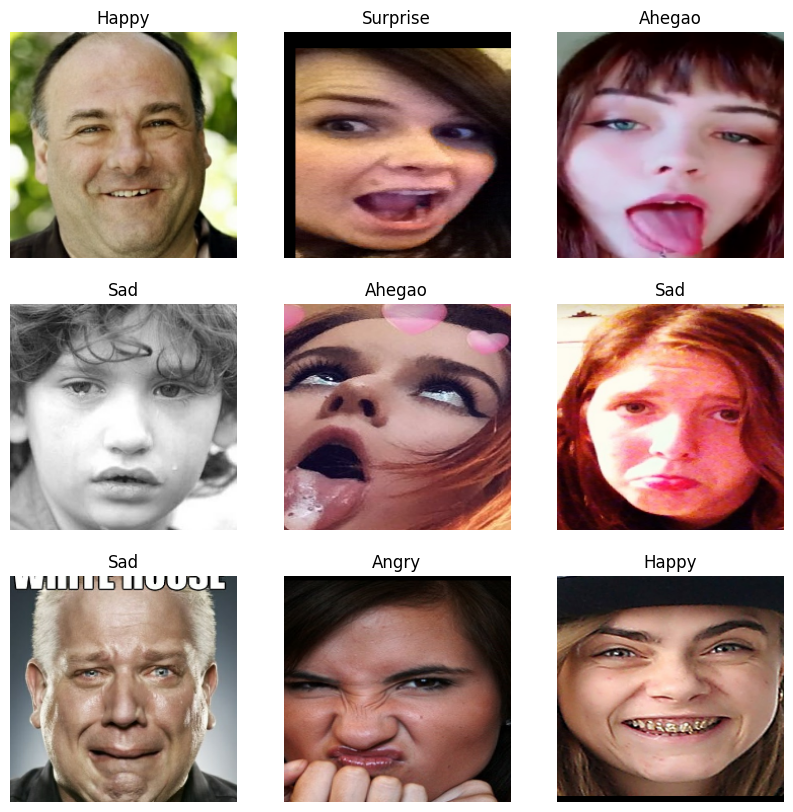

In [ ]:
# Show the first nine images and labels from the training set:

class_names = ds_train.class_names

plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# As the original dataset doesn't contain a test set, you will create one.
# To do so, determine how many batches of data are available in the validation set
# using tf.data.experimental.cardinality, then move 20% of them to a test set.
val_batches = tf.data.experimental.cardinality(ds_validation)
ds_test = ds_validation.take(val_batches // 5)
ds_validation = ds_validation.skip(val_batches // 5)

In [ ]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(ds_validation))
print('Number of test batches: %d' % tf.data.experimental.cardinality(ds_test))

Number of validation batches: 36
Number of test batches: 9


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.prefetch(buffer_size=AUTOTUNE)
ds_validation = ds_validation.prefetch(buffer_size=AUTOTUNE)
ds_test = ds_test.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Rescale pixel values
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [ ]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')  # use imagenet that is pretrian weight and cut head layer so tnclude_top = false

In [ ]:
# This feature extractor converts each 160x160x3 image into a 5x5x1280 block
# of features. Let's see what it does to an example batch of images:

image_batch, label_batch = next(iter(ds_train))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(16, 7, 7, 1280)


In [ ]:
# Freeze the convolutional base
base_model.trainable = False # use pretrian weight

In [ ]:
# Let's take a look at the base model architecture
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Add custom model so train only custom model bcoz the convolutional base was freeze
# average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.layers[-2].output)  Flatten
average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
prediction_layer  = tf.keras.layers.Dense(units=15, activation='softmax')(average_pooling_layer)

In [ ]:
model = tf.keras.models.Model(inputs = base_model.input, outputs = prediction_layer)

In [ ]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the model
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

In [ ]:
# model.fit_generator(train_generator, epochs=10, validation_data = valid_generator)
model.fit(ds_train,
                    epochs=10,
                    validation_data=ds_validation)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 259ms/step - accuracy: 0.1700 - loss: 2.5311 - val_accuracy: 0.1504 - val_loss: 2.7425
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 108s 269ms/step - accuracy: 0.3195 - loss: 2.0778 - val_accuracy: 0.2584 - val_loss: 3.0624
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 280ms/step - accuracy: 0.7232 - loss: 0.8705 - val_accuracy: 0.4425 - val_loss: 2.0709
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 279ms/step - accuracy: 0.8944 - loss: 0.3305 - val_accuracy: 0.6283 - val_loss: 1.2072
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 110s 275ms/step - accuracy: 0.9444 - loss: 0.1717 - val_accuracy: 0.6071 - val_loss: 1.3566
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 110s 274ms/step - accuracy: 0.9642 - loss: 0.1037 - val_accuracy: 0.7097 - val_loss: 0.9338
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 280ms/step - accuracy: 0.9747 - loss: 0.0852 - val_accuracy: 0.8018 - val_loss: 0.6512
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 111s 277ms/step - accuracy: 0.9823 -

In [ ]:
# Un-freeze the top layers of the model
base_model.trainable = True
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer => fix weight and bias from layer 0 to 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [ ]:
# Compile the model
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

In [ ]:
# model.fit_generator(train_generator, epochs=10, validation_data = valid_generator)
model.fit(ds_train,
                    epochs=10,
                    validation_data=ds_validation)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 113s 260ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.8460 - val_loss: 0.8098
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 109s 272ms/step - accuracy: 0.9864 - loss: 0.0467 - val_accuracy: 0.8478 - val_loss: 0.6221
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 108s 269ms/step - accuracy: 0.9824 - loss: 0.0470 - val_accuracy: 0.8743 - val_loss: 0.6684
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 109s 272ms/step - accuracy: 0.9861 - loss: 0.0377 - val_accuracy: 0.8230 - val_loss: 0.9205
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 255ms/step - accuracy: 0.9873 - loss: 0.0413 - val_accuracy: 0.8779 - val_loss: 0.7143
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 101s 252ms/step - accuracy: 0.9867 - loss: 0.0364 - val_accuracy: 0.8690 - val_loss: 0.7403
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 254ms/step - accuracy: 0.9860 - loss: 0.0391 - val_accuracy: 0.8407 - val_loss: 0.9489
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 254ms/step - accuracy: 0.9890 -